# Buổi 4: Tìm kiếm trong không gian trạng thái

# Bài tập 2:
Bài toán **Mê cung**: Tìm đường đi để con kiến có thể đi tới ô A trong mê cung cho bên dưới: <br>
<br>
![image](mecung.png)

## Tạo cấu trúc tường trong mê cung và MinHeap

In [14]:
import heapq

class Wall:
    def __init__(self, x1=0, y1=0, x2=0, y2=0):
        self.a = (x1,y1)
        self.b = (x2,y2)
        pass
    def __eq__(self, other):
        return {self.a, self.b} == {other.a, other.b}
    def __repr__(self):
        return f"({self.a},{self.b})"
    def __hash__(self):
        return hash(frozenset([self.a,self.b]))
        
    pass

# Xây dựng MinHeap
class MinHeap(object):
    def __init__(self):                         # Khởi tạo MinHeap rỗng
        self.items = []
        pass
    
    def empty(self):                            # Kiểm tra heap rỗng
        return len(self.items)==0
  
    def push(self, item):                       # Đưa một item vào MinHeap
        heapq.heappush(self.items, item)
        pass
  
    def pop(self):                              # Lấy 1 item có giá trị nhỏ nhất ra khỏi MinHeap
        item = heapq.heappop(self.items)
        return item
    
    def check(self, item):                      # Kiểm tra item có nằm trong MinHeap
        return item in self.items
    
    def update(self, item, new_item):           # Cập nhật lại new_item từ item cho trước
        for i in range(len(self.items)):
            if self.items[i] == item:
                self.items[i] = new_item
                heapq.heapify(self.items)
        pass
    pass # MinHeap

**maze.inp**
```
(Dựa theo dòng cột base 1)
6           # m = 6
6           # n = 6
1 2 1 3     # tường giữa ô [1,2] và [1,3]
2 2 2 3
3 5 4 5
3 6 4 6
5 2 5 3
6 2 6 3
```

## Đọc dữ liệu

In [15]:
from ex2_maze import readfile
wall_list, maze = readfile()

Ma trận : 
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]
Danh sách vị trí các tường
[((np.int64(1), np.int64(2)),(np.int64(1), np.int64(3))), ((np.int64(2), np.int64(2)),(np.int64(2), np.int64(3))), ((np.int64(3), np.int64(5)),(np.int64(4), np.int64(5))), ((np.int64(3), np.int64(6)),(np.int64(4), np.int64(6))), ((np.int64(5), np.int64(2)),(np.int64(5), np.int64(3))), ((np.int64(6), np.int64(2)),(np.int64(6), np.int64(3)))]


## 1. Tìm đường đi từ ô (1,1) đến ô (6,6) của mê cung bằng thuật toán Best First Search

### a. Cài đặt thuật toán

In [16]:
import pprint
from ex2_maze import find_path_UCS

#..
parent = find_path_UCS(maze, wall_list, 1, 1, 6, 6)

pprint.pprint(parent)

{(1, 1): None,
 (1, 2): (1, 1),
 (1, 3): (2, 3),
 (1, 4): (1, 3),
 (1, 5): (1, 4),
 (1, 6): (1, 5),
 (2, 1): (1, 1),
 (2, 2): (1, 2),
 (2, 3): (3, 3),
 (2, 4): (2, 3),
 (2, 5): (2, 4),
 (2, 6): (2, 5),
 (3, 1): (2, 1),
 (3, 2): (2, 2),
 (3, 3): (3, 2),
 (3, 4): (3, 3),
 (3, 5): (3, 4),
 (3, 6): (3, 5),
 (4, 1): (3, 1),
 (4, 2): (3, 2),
 (4, 3): (3, 3),
 (4, 4): (3, 4),
 (4, 5): (4, 4),
 (4, 6): (4, 5),
 (5, 1): (4, 1),
 (5, 2): (4, 2),
 (5, 3): (4, 3),
 (5, 4): (4, 4),
 (5, 5): (4, 5),
 (5, 6): (4, 6),
 (6, 1): (5, 1),
 (6, 2): (5, 2),
 (6, 3): (5, 3),
 (6, 4): (5, 4),
 (6, 5): (5, 5),
 (6, 6): (5, 6)}


### b. Truy vết đường đi

In [17]:
import pprint
from ex2_maze import path

result = path(parent, 1,1,6,6)

pprint.pprint(result)


[(6, 6),
 (5, 6),
 (4, 6),
 (4, 5),
 (4, 4),
 (3, 4),
 (3, 3),
 (3, 2),
 (2, 2),
 (1, 2),
 (1, 1)]


### c. Vẽ lại đường đi

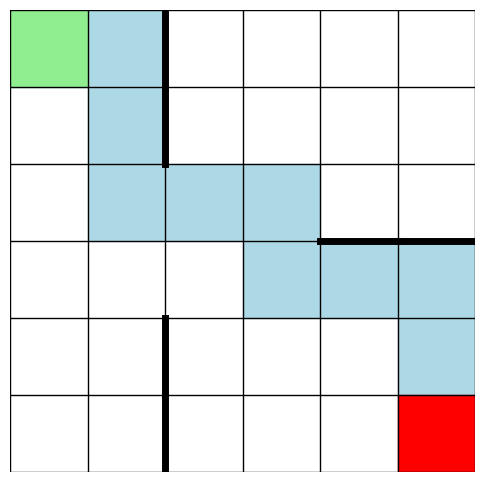

In [18]:
import matplotlib.pyplot as plt 


def draw_path(result, matrix_size, wall_list, start, goal):
    m, n = matrix_size
    
    # Vẽ lưới
    for i in range(m+1):
        plt.plot([0,n],[i,i], color='black', linewidth=1)
    for j in range(n+1):
        plt.plot([j,j],[0,m], color='black', linewidth=1)

    plt.gca().invert_yaxis()
    plt.axis("off")

    # Vẽ tường
    for wall in wall_list:
        r1, c1 = wall.a
        r2, c2 = wall.b

        r1 -= 1; c1 -= 1
        r2 -= 1; c2 -= 1

        if r1 == r2:  # tường đứng
            r = r1
            c = max(c1,c2)
            plt.plot([c,c], [r, r+1], linewidth=5, color="black")
        elif c1 == c2:  # tường ngang
            c = c1
            r = max(r1,r2)
            plt.plot([c,c+1], [r, r], linewidth=5, color="black")

    # Tô đường đi
    for (r,c) in result:
        r -= 1; c -= 1
        plt.fill(
            [c, c+1, c+1, c],
            [r, r, r+1, r+1],
            color='lightblue'
        )

    # Tô start
    sr, sc = start
    sr -= 1; sc -= 1
    plt.fill([sc, sc+1, sc+1, sc],
             [sr, sr, sr+1, sr+1],
             color='lightgreen')

    # Tô goal
    gr, gc = goal
    gr -= 1; gc -= 1
    plt.fill([gc, gc+1, gc+1, gc],
             [gr, gr, gr+1, gr+1],
             color='red')
    
n = 6
plt.figure(figsize=(6,6))
plt.xlim(0,n)
plt.ylim(0,n)
draw_path(result, maze.shape, wall_list, start=(1,1), goal=(n,n))
plt.savefig("maze_ucs.png")
plt.show()

### d. Kiểm tra với testcase

## 2. Tìm đường đi từ ô (1,1) đến ô (6,6) của mê cung bằng thuật toán A*

### a .Tính toán heuristic trên ma trận
Dựa trên khoảng cách Manhattan của ô hiện tại đến ô đích theo công thức: $$h(n) = |(x - x_{goal})|+|(y-y_{goal})|$$

### b. Cài đặt thuật toán

In [19]:
import pprint
from ex2_maze import find_path_AStar

#..
parent2 = find_path_AStar(maze, wall_list, 1, 1, 6, 6)

pprint.pprint(parent)

{(1, 1): None,
 (1, 2): (1, 1),
 (1, 3): (2, 3),
 (1, 4): (1, 3),
 (1, 5): (1, 4),
 (1, 6): (1, 5),
 (2, 1): (1, 1),
 (2, 2): (1, 2),
 (2, 3): (3, 3),
 (2, 4): (2, 3),
 (2, 5): (2, 4),
 (2, 6): (2, 5),
 (3, 1): (2, 1),
 (3, 2): (2, 2),
 (3, 3): (3, 2),
 (3, 4): (3, 3),
 (3, 5): (3, 4),
 (3, 6): (3, 5),
 (4, 1): (3, 1),
 (4, 2): (3, 2),
 (4, 3): (3, 3),
 (4, 4): (3, 4),
 (4, 5): (4, 4),
 (4, 6): (4, 5),
 (5, 1): (4, 1),
 (5, 2): (4, 2),
 (5, 3): (4, 3),
 (5, 4): (4, 4),
 (5, 5): (4, 5),
 (5, 6): (4, 6),
 (6, 1): (5, 1),
 (6, 2): (5, 2),
 (6, 3): (5, 3),
 (6, 4): (5, 4),
 (6, 5): (5, 5),
 (6, 6): (5, 6)}


### c. Truy vết đường đi

In [20]:
import pprint
from ex2_maze import path

result2 = path(parent2, 1,1,6,6)

pprint.pprint(result2)

[(6, 6),
 (5, 6),
 (4, 6),
 (4, 5),
 (4, 4),
 (3, 4),
 (3, 3),
 (3, 2),
 (2, 2),
 (1, 2),
 (1, 1)]


### d. Vẽ lại đường đi

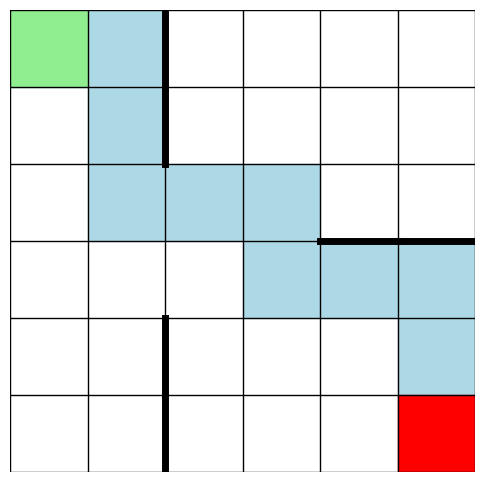

In [21]:
plt.figure(figsize=(6,6))
plt.xlim(0,6)
plt.ylim(0,6)
draw_path(result2, maze.shape, wall_list, start=(1,1), goal=(6,6))
plt.savefig("maze_Astar.png")
plt.show()

# Kết thúc